## **i. Mount google drive**
---

In [0]:
from google.colab import drive
drive.mount('/content/gdrive')

## **ii. Import the libraries**
---

In [ ]:
import cv2

In [4]:
import sys
import os
import scipy
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("Versions of key libraries")
print("---")
print("numpy:     ", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:    ", pd.__version__)
print("scipy:     ", scipy.__version__)


Versions of key libraries
---
numpy:      2.3.3
matplotlib: 3.10.6
pandas:     2.3.2
scipy:      1.16.2


In [1]:
print(sys.executable)

/hpctmp/e1554287/conda/envs/ai1008/bin/python


## **iii. Append /iss/issm/data/ in your python path**
---

In [0]:
sys.path.append('/content/gdrive/My Drive/iss/issm/data/')
print("All the system paths:")
sys.path

## **iv. Change working directory to /iss/issm/data/**
---

In [0]:
os.chdir('/content/gdrive/My Drive/iss/issm/data/')
print("Current working directory:")
os.getcwd()

## **v. Setup matplotlib**
---

In [5]:
plt.style.use('ggplot')                   # if want to use the default style, set 'classic'
plt.rcParams['ytick.right']     = True
plt.rcParams['ytick.labelright']= True
plt.rcParams['ytick.left']      = False
plt.rcParams['ytick.labelleft'] = False

print("Matplotlib setup completes.")

Matplotlib setup completes.


## **1. Part 1: Perform peak detection**
---
* Step 1: Read in the ecg signals
* Step 2: Perform peak detection
* Step 3: Display detected peaks

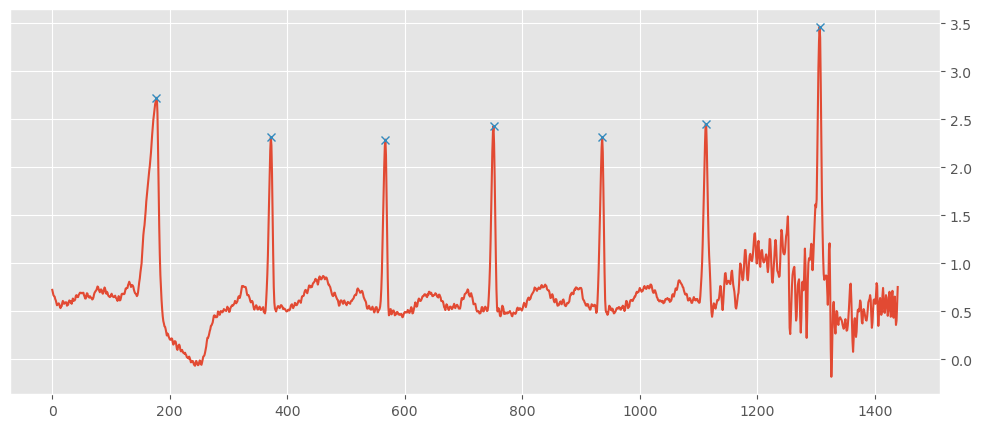

In [6]:
# Type your code below 

from scipy.signal import find_peaks as findPeaks

# Step 1
l2D = pd.read_csv('ecg2D.csv',
                      header=None)

# Chose 2nd Column within the Dataset as the interested signal
ECGs = l2D[1].values

(Pks,_) = findPeaks(ECGs,prominence=0.5,distance=100) # Step 2

 # Step 3
plt.figure(figsize=(12,5))
plt.plot(ECGs)
plt.plot(Pks,ECGs[Pks],'x')

## **Part 2: Baseline correction**
---
* Step 1: Create the baseline correction function
* Step 2: Perform baseline correction
* Step 3: Display the output

/var/tmp/pbs.180628.venus01/ipykernel_39779/283402163.py:15: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)


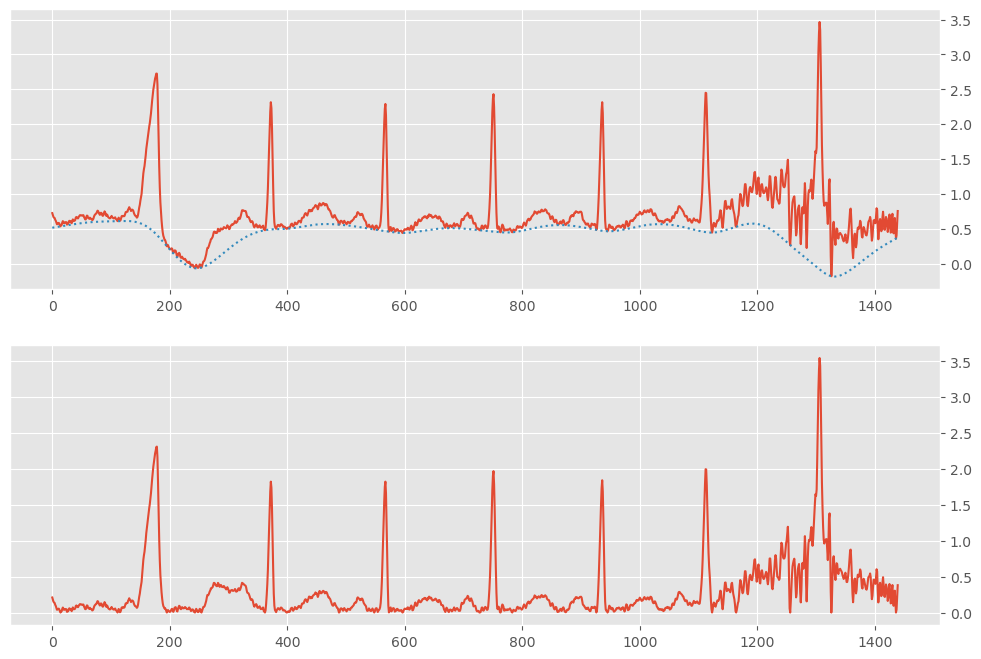

In [7]:
# Type your code below

 # Step 1
from scipy import sparse
from scipy.sparse.linalg import spsolve

def alsbase(y, lam, p, niter=10):
    L = len(y)
    D = sparse.diags([1,-2,1],[0,-1,-2], shape=(L,L-2))
    w = np.ones(L)

    for i in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        Z = W + lam * D.dot(D.transpose())
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1-p) * (y < z)
    return z

 # Step 2
ecgbase = alsbase(ECGs, 10^5,0.000005,niter=50)
                                # 10^5 for lam, 0.000005 for p, 50 for iter
ecgcorr = ECGs-ecgbase

 # Step 3
plt.figure(figsize=(12,8))
plt.subplot(211)
plt.plot(ECGs)

plt.plot(ecgbase,
         color="C1",
         linestyle='dotted')
plt.subplot(212)
plt.plot(ecgcorr)